In [ ]:
# Part 1. Data Collection and Initial Setup ------------------------------------------------------------------- 


In [48]:
# Import required libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd


In [ ]:
# Created empty lists to store data

titles = []
prices = []
stocks = []

for page in range(1, 51):          
    url = f"http://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.select(".product_pod")

    for b in books:
        title = b.h3.a["title"]
        price = b.select_one(".price_color").text
        stock = b.select_one(".availability").text.strip()

        titles.append(title)
        prices.append(price)
        stocks.append(stock)

print("Total books scraped:", len(titles))


Total books scraped: 1000


In [ ]:
# Created DataFrame

df = pd.DataFrame({
    "Title": titles,
    "Raw_Price": prices,
    "Availability": stocks
})



,Title,Raw_Price,Availability
0,A Light in the Attic,Â£51.77,In stock
1,Tipping the Velvet,Â£53.74,In stock
2,Soumission,Â£50.10,In stock
3,Sharp Objects,Â£47.82,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock
5,The Requiem Red,Â£22.65,In stock
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,In stock
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,In stock
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,In stock
9,The Black Maria,Â£52.15,In stock


In [9]:
# Fix encoding issue (remove the 'Â' character)
df["Raw_Price"] = df["Raw_Price"].str.replace("Â", "", regex=False)
df.head(5)


,Title,Raw_Price,Availability
0,A Light in the Attic,£51.77,In stock
1,Tipping the Velvet,£53.74,In stock
2,Soumission,£50.10,In stock
3,Sharp Objects,£47.82,In stock
4,Sapiens: A Brief History of Humankind,£54.23,In stock


In [10]:
# Remove weird encoding symbols
df["Raw_Price"] = df["Raw_Price"].str.replace("Â", "", regex=False)

# Cleaned spaces and text in Availability column
df["Availability"] = df["Availability"].str.strip()


In [11]:
df.head(10)


,Title,Raw_Price,Availability
0,A Light in the Attic,£51.77,In stock
1,Tipping the Velvet,£53.74,In stock
2,Soumission,£50.10,In stock
3,Sharp Objects,£47.82,In stock
4,Sapiens: A Brief History of Humankind,£54.23,In stock
5,The Requiem Red,£22.65,In stock
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,In stock
7,The Coming Woman: A Novel Based on the Life of...,£17.93,In stock
8,The Boys in the Boat: Nine Americans and Their...,£22.60,In stock
9,The Black Maria,£52.15,In stock


In [12]:
# Converted price from £ to USD (1 £ = 1.25 USD)
df["Price_USD"] = df["Raw_Price"].str.extract(r"£(\d+\.\d+)").astype(float) * 1.25


In [13]:
df.head(10)


,Title,Raw_Price,Availability,Price_USD
0,A Light in the Attic,£51.77,In stock,64.7125
1,Tipping the Velvet,£53.74,In stock,67.1750
2,Soumission,£50.10,In stock,62.6250
3,Sharp Objects,£47.82,In stock,59.7750
4,Sapiens: A Brief History of Humankind,£54.23,In stock,67.7875
5,The Requiem Red,£22.65,In stock,28.3125
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,In stock,41.6750
7,The Coming Woman: A Novel Based on the Life of...,£17.93,In stock,22.4125
8,The Boys in the Boat: Nine Americans and Their...,£22.60,In stock,28.2500
9,The Black Maria,£52.15,In stock,65.1875


In [14]:
# Removed Stock_Count (constant) to keep dataset informative


In [15]:
df.head(10)


,Title,Raw_Price,Availability,Price_USD,Stock_Count
0,A Light in the Attic,£51.77,In stock,64.7125,1
1,Tipping the Velvet,£53.74,In stock,67.1750,1
2,Soumission,£50.10,In stock,62.6250,1
3,Sharp Objects,£47.82,In stock,59.7750,1
4,Sapiens: A Brief History of Humankind,£54.23,In stock,67.7875,1
5,The Requiem Red,£22.65,In stock,28.3125,1
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,In stock,41.6750,1
7,The Coming Woman: A Novel Based on the Life of...,£17.93,In stock,22.4125,1
8,The Boys in the Boat: Nine Americans and Their...,£22.60,In stock,28.2500,1
9,The Black Maria,£52.15,In stock,65.1875,1


In [20]:
df.dtypes


Title            object
Raw_Price        object
Availability     object
Price_USD       float64
Stock_Count       int64
dtype: object

In [ ]:
# Part 2. Data Wrangling --------------------------------------------------------------------------------------


In [ ]:
# Task A: Unit Conversion, Data Type Correction, and Formatting 


In [22]:
df.head()

,Title,Raw_Price,Availability,Price_USD,Stock_Count,Price_per_Stock
0,A Light in the Attic,£51.77,In stock,64.7125,1,64.7125
1,Tipping the Velvet,£53.74,In stock,67.1750,1,67.1750
2,Soumission,£50.10,In stock,62.6250,1,62.6250
3,Sharp Objects,£47.82,In stock,59.7750,1,59.7750
4,Sapiens: A Brief History of Humankind,£54.23,In stock,67.7875,1,67.7875


In [25]:
df.dtypes


Title               object
Raw_Price           object
Availability        object
Price_USD          float64
Stock_Count          int64
Price_per_Stock    float64
dtype: object

In [26]:
df.head(10)


,Title,Raw_Price,Availability,Price_USD,Stock_Count,Price_per_Stock
0,A Light in the Attic,£51.77,In stock,64.7125,1,64.7125
1,Tipping the Velvet,£53.74,In stock,67.1750,1,67.1750
2,Soumission,£50.10,In stock,62.6250,1,62.6250
3,Sharp Objects,£47.82,In stock,59.7750,1,59.7750
4,Sapiens: A Brief History of Humankind,£54.23,In stock,67.7875,1,67.7875
5,The Requiem Red,£22.65,In stock,28.3125,1,28.3125
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,In stock,41.6750,1,41.6750
7,The Coming Woman: A Novel Based on the Life of...,£17.93,In stock,22.4125,1,22.4125
8,The Boys in the Boat: Nine Americans and Their...,£22.60,In stock,28.2500,1,28.2500
9,The Black Maria,£52.15,In stock,65.1875,1,65.1875


In [28]:
# Normalized Price_USD using Min-Max scaling
df["Price_MinMax"] = (df["Price_USD"] - df["Price_USD"].min()) / (df["Price_USD"].max() - df["Price_USD"].min())


In [29]:
df.head(10)


,Title,Raw_Price,Availability,Price_USD,Stock_Count,Price_per_Stock,Stock_ZScore,Price_MinMax
0,A Light in the Attic,£51.77,In stock,64.7125,1,64.7125,NaN,0.835567
1,Tipping the Velvet,£53.74,In stock,67.1750,1,67.1750,NaN,0.874975
2,Soumission,£50.10,In stock,62.6250,1,62.6250,NaN,0.802160
3,Sharp Objects,£47.82,In stock,59.7750,1,59.7750,NaN,0.756551
4,Sapiens: A Brief History of Humankind,£54.23,In stock,67.7875,1,67.7875,NaN,0.884777
5,The Requiem Red,£22.65,In stock,28.3125,1,28.3125,NaN,0.253051
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,In stock,41.6750,1,41.6750,NaN,0.466893
7,The Coming Woman: A Novel Based on the Life of...,£17.93,In stock,22.4125,1,22.4125,NaN,0.158632
8,The Boys in the Boat: Nine Americans and Their...,£22.60,In stock,28.2500,1,28.2500,NaN,0.252050
9,The Black Maria,£52.15,In stock,65.1875,1,65.1875,NaN,0.843169


In [30]:
df[["Price_USD", "Price_MinMax"]].describe()


,Stock_Count,Stock_ZScore,Price_USD,Price_MinMax
count,1000.0,0.0,1000.000000,1000.000000
mean,1.0,NaN,43.837938,0.501507
std,0.0,NaN,18.058362,0.288992
min,1.0,NaN,12.500000,0.000000
25%,1.0,NaN,27.634375,0.242198
50%,1.0,NaN,44.975000,0.519704
75%,1.0,NaN,59.321875,0.749300
max,1.0,NaN,74.987500,1.000000


In [ ]:
# Task C: Advanced Binning and Categorical Conversion 


In [31]:
import numpy as np
import matplotlib.pyplot as plt


In [32]:
# Created 3 bins for Low / Medium / High price ranges
bins = np.linspace(df["Price_USD"].min(), df["Price_USD"].max(), 4)
labels = ["Low", "Medium", "High"]

df["Price_Category"] = pd.cut(df["Price_USD"], bins=bins, labels=labels, include_lowest=True)


In [33]:
df.head(10)


,Title,Raw_Price,Availability,Price_USD,Stock_Count,Price_per_Stock,Stock_ZScore,Price_MinMax,Price_Category
0,A Light in the Attic,£51.77,In stock,64.7125,1,64.7125,NaN,0.835567,High
1,Tipping the Velvet,£53.74,In stock,67.1750,1,67.1750,NaN,0.874975,High
2,Soumission,£50.10,In stock,62.6250,1,62.6250,NaN,0.802160,High
3,Sharp Objects,£47.82,In stock,59.7750,1,59.7750,NaN,0.756551,High
4,Sapiens: A Brief History of Humankind,£54.23,In stock,67.7875,1,67.7875,NaN,0.884777,High
5,The Requiem Red,£22.65,In stock,28.3125,1,28.3125,NaN,0.253051,Low
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,In stock,41.6750,1,41.6750,NaN,0.466893,Medium
7,The Coming Woman: A Novel Based on the Life of...,£17.93,In stock,22.4125,1,22.4125,NaN,0.158632,Low
8,The Boys in the Boat: Nine Americans and Their...,£22.60,In stock,28.2500,1,28.2500,NaN,0.252050,Low
9,The Black Maria,£52.15,In stock,65.1875,1,65.1875,NaN,0.843169,High


In [34]:
df["Price_Category"].value_counts()


Price_Category
High      340
Low       331
Medium    329
Name: count, dtype: int64

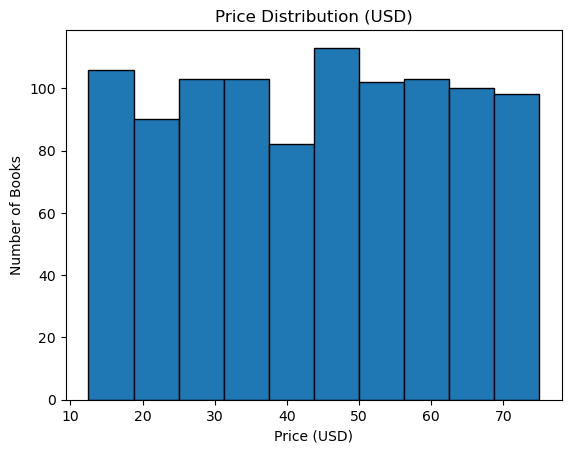

In [35]:
# Plot histogram to visualize price distribution

plt.hist(df["Price_USD"], bins=10, edgecolor="black")
plt.title("Price Distribution (USD)")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Books")
plt.show()


In [36]:
# Converted categorical column into dummy variables 

df = pd.get_dummies(df, columns=["Price_Category"])
df.head(10)


,Title,Raw_Price,Availability,Price_USD,Stock_Count,Price_per_Stock,Stock_ZScore,Price_MinMax,Price_Category_Low,Price_Category_Medium,Price_Category_High
0,A Light in the Attic,£51.77,In stock,64.7125,1,64.7125,NaN,0.835567,False,False,True
1,Tipping the Velvet,£53.74,In stock,67.1750,1,67.1750,NaN,0.874975,False,False,True
2,Soumission,£50.10,In stock,62.6250,1,62.6250,NaN,0.802160,False,False,True
3,Sharp Objects,£47.82,In stock,59.7750,1,59.7750,NaN,0.756551,False,False,True
4,Sapiens: A Brief History of Humankind,£54.23,In stock,67.7875,1,67.7875,NaN,0.884777,False,False,True
5,The Requiem Red,£22.65,In stock,28.3125,1,28.3125,NaN,0.253051,True,False,False
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,In stock,41.6750,1,41.6750,NaN,0.466893,False,True,False
7,The Coming Woman: A Novel Based on the Life of...,£17.93,In stock,22.4125,1,22.4125,NaN,0.158632,True,False,False
8,The Boys in the Boat: Nine Americans and Their...,£22.60,In stock,28.2500,1,28.2500,NaN,0.252050,True,False,False
9,The Black Maria,£52.15,In stock,65.1875,1,65.1875,NaN,0.843169,False,False,True


In [37]:
df["Price_Category_Low"].value_counts()


Price_Category_Low
False    669
True     331
Name: count, dtype: int64

In [ ]:
# Part 3. Exploratory Data Analysis --------------------------------------------------------------------------------


In [ ]:
# Task D – Statistical Summary and Distribution


In [38]:
# Show statistical summary of numeric columns

df[["Price_USD", "Price_MinMax"]].describe()


In [39]:
# Created  readable category label column

def get_price_category(row):
    if row["Price_Category_Low"]:
        return "Low"
    elif row["Price_Category_Medium"]:
        return "Medium"
    else:
        return "High"

df["Category_Label"] = df.apply(get_price_category, axis=1)


In [40]:
# Group by category to find average price

avg_price_by_category = df.groupby("Category_Label")["Price_USD"].mean().reset_index()
avg_price_by_category


,Category_Label,Price_USD
0,High,64.289669
1,Low,22.720997
2,Medium,43.947720


In [41]:
# Create pivot table showing same result

pivot_table = df.pivot_table(values="Price_USD", index="Category_Label", aggfunc="mean")
pivot_table


,Price_USD
Category_Label,
High,64.289669
Low,22.720997
Medium,43.947720


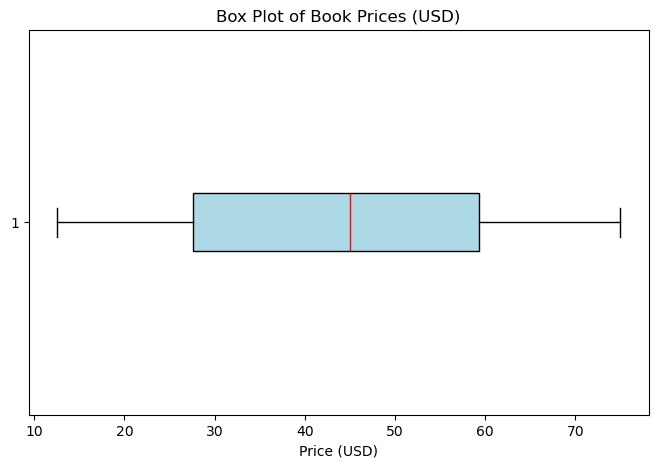

In [42]:
# Box plot to see median, quartiles, outliers

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df["Price_USD"], vert=False, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="black"),
            medianprops=dict(color="red"))
plt.title("Box Plot of Book Prices (USD)")
plt.xlabel("Price (USD)")
plt.show()


In [1]:
# Task E: Price Extremes (Top Expensive/Cheapest) 


In [43]:
import matplotlib.pyplot as plt
from scipy import stats


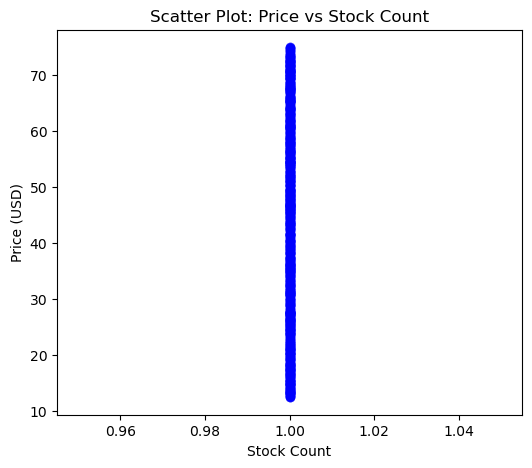

In [44]:
# Top 10 most expensive books (by Price_USD)

top_expensive = df.sort_values("Price_USD", ascending=False)[["Title", "Price_USD", "Availability"]].head(10)
top_expensive


In [45]:
# Top 10 cheapest books (by Price_USD)

top_cheapest = df.sort_values("Price_USD", ascending=True)[["Title", "Price_USD", "Availability"]].head(10)
top_cheapest


In [ ]:
# Task F: Average Price by Category (Binned) 


In [46]:
# Average price by price category

avg_price_by_category = df.groupby("Category_Label")["Price_USD"].mean().reset_index()
avg_price_by_category


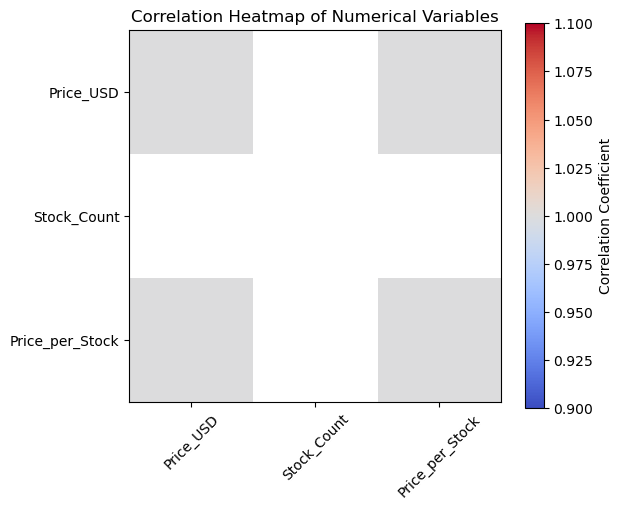

In [47]:
# Bar plot of average price by price category

plt.figure(figsize=(7,4))
plt.bar(avg_price_by_category["Category_Label"], avg_price_by_category["Price_USD"], color="skyblue", edgecolor="black")
plt.title("Average Price by Price Category (USD)")
plt.xlabel("Price Category")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
